In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join('..')))

from src.preprocess import TextPreprocessor

sns.set_theme(style="whitegrid")
%matplotlib inline

print("Environment setup complete. Pipeline dependencies successfully imported.")

Environment setup complete. Pipeline dependencies successfully imported.


In [2]:
data_path = os.path.join('..', 'data', 'spam.csv')

try:
    df = pd.read_csv(data_path, encoding='latin1')
    print(f"Dataset successfully loaded with shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: Raw file not found at {data_path}. Please make sure 'spam.csv' is in the data/ directory.")

preprocessor = TextPreprocessor()
processed_df = preprocessor.process_dataframe(df)

print("\nProcessed Data Columns:", processed_df.columns.tolist())
processed_df[['label', 'message', 'cleaned_message']].head()

Dataset successfully loaded with shape: (5572, 5)

Processed Data Columns: ['label', 'message', 'cleaned_message']


,label,message,cleaned_message
0,0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,0,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


C:\Users\vijay\AppData\Local\Temp\ipykernel_31428\3049935266.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='label', data=processed_df, palette=['#22C55E', '#EF4444'])
C:\Users\vijay\AppData\Local\Temp\ipykernel_31428\3049935266.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Ham (0)', 'Spam (1)'])


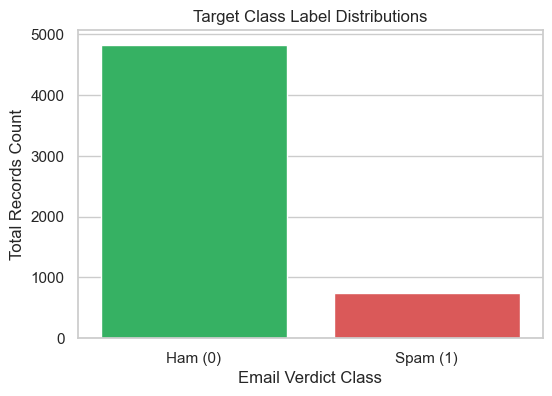

--- Descriptives Summary (Ham vs Spam Text Length) ---
       char_count  word_count
label                        
0       71.023627   14.200622
1      138.866131   23.851406


In [3]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='label', data=processed_df, palette=['#22C55E', '#EF4444'])
ax.set_xticklabels(['Ham (0)', 'Spam (1)'])
plt.title('Target Class Label Distributions')
plt.xlabel('Email Verdict Class')
plt.ylabel('Total Records Count')
plt.show()

processed_df['char_count'] = processed_df['message'].apply(len)
processed_df['word_count'] = processed_df['message'].apply(lambda x: len(x.split()))

print("--- Descriptives Summary (Ham vs Spam Text Length) ---")
print(processed_df.groupby('label')[['char_count', 'word_count']].mean())

In [4]:
from sklearn.model_selection import train_test_split

X = processed_df['cleaned_message']
y = processed_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y
)

print(f"Training split samples: {X_train.shape[0]}")
print(f"Testing split samples: {X_test.shape[0]}")

Training split samples: 3733
Testing split samples: 1839


In [5]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

model_performance = {}

In [6]:
bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

y_pred_nb = nb_model.predict(X_test_bow)
nb_acc = accuracy_score(y_test, y_pred_nb)
model_performance['NB (CountVectorizer)'] = nb_acc

print("=== Multinomial Naive Bayes Performance Classification Report ===")
print(classification_report(y_test, y_pred_nb, target_names=['Ham', 'Spam']))

=== Multinomial Naive Bayes Performance Classification Report ===
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99      1592
        Spam       0.93      0.89      0.91       247

    accuracy                           0.98      1839
   macro avg       0.96      0.94      0.95      1839
weighted avg       0.98      0.98      0.98      1839



In [7]:

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_bow, y_train)

y_pred_log = log_model.predict(X_test_bow)
log_acc = accuracy_score(y_test, y_pred_log)
model_performance['Logistic Regression (CountVectorizer)'] = log_acc

print("=== Logistic Regression Performance Classification Report ===")
print(classification_report(y_test, y_pred_log, target_names=['Ham', 'Spam']))

=== Logistic Regression Performance Classification Report ===
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99      1592
        Spam       1.00      0.86      0.92       247

    accuracy                           0.98      1839
   macro avg       0.99      0.93      0.96      1839
weighted avg       0.98      0.98      0.98      1839



In [8]:

tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

tree_model = DecisionTreeClassifier(criterion='gini', max_depth=20, random_state=42)
tree_model.fit(X_train_tfidf, y_train)


y_pred_tree = tree_model.predict(X_test_tfidf)
tree_acc = accuracy_score(y_test, y_pred_tree)
model_performance['Decision Tree (TF-IDF)'] = tree_acc

print("=== Decision Tree Performance Classification Report ===")
print(classification_report(y_test, y_pred_tree, target_names=['Ham', 'Spam']))

=== Decision Tree Performance Classification Report ===
              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98      1592
        Spam       0.92      0.80      0.85       247

    accuracy                           0.96      1839
   macro avg       0.94      0.89      0.92      1839
weighted avg       0.96      0.96      0.96      1839



C:\Users\vijay\AppData\Local\Temp\ipykernel_31428\1500698532.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Accuracy Score', y='Pipeline Combination', data=perf_df, palette='viridis')


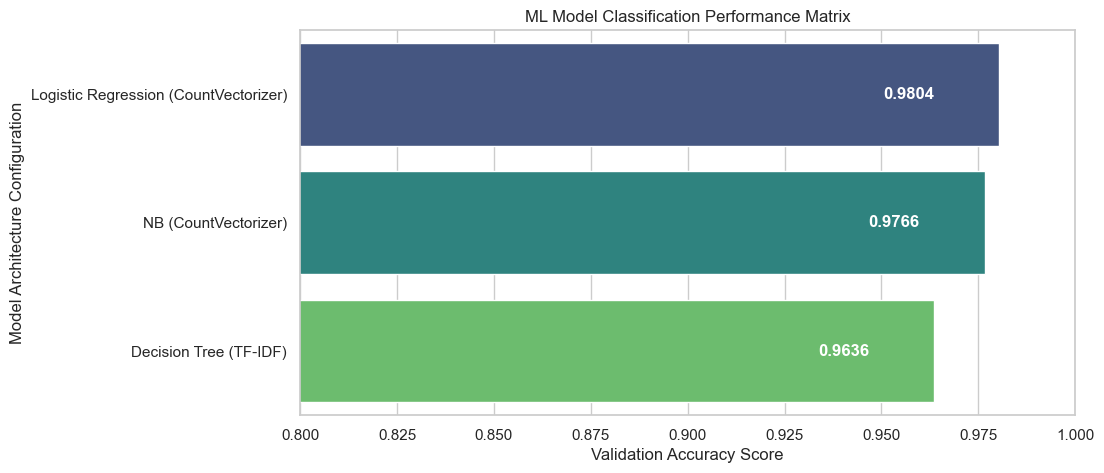

Conclusion Recommendation:
The highest performing setup variant is 'Logistic Regression (CountVectorizer)' with an accuracy score of 0.9804.
This configuration handles deployment paths natively inside standard asset storage directory blocks via 'src/train.py'.


In [9]:

perf_df = pd.DataFrame(list(model_performance.items()), columns=['Pipeline Combination', 'Accuracy Score'])
perf_df = perf_df.sort_values(by='Accuracy Score', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x='Accuracy Score', y='Pipeline Combination', data=perf_df, palette='viridis')
plt.xlim(0.8, 1.0)
plt.title('ML Model Classification Performance Matrix')
plt.xlabel('Validation Accuracy Score')
plt.ylabel('Model Architecture Configuration')

for index, value in enumerate(perf_df['Accuracy Score']):
    plt.text(value - 0.03, index, f"{value:.4f}", color='white', va='center', fontweight='bold')

plt.show()

print("Conclusion Recommendation:")
print(f"The highest performing setup variant is '{perf_df.iloc[0]['Pipeline Combination']}' with an accuracy score of {perf_df.iloc[0]['Accuracy Score']:.4f}.")
print("This configuration handles deployment paths natively inside standard asset storage directory blocks via 'src/train.py'.")
